# Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on an e-commerce dataset to uncover customer purchasing behavior, sales trends, revenue patterns, operational insights, and business opportunities through statistical analysis and data visualization techniques.

# Import Libraries

In this section, the required Python libraries for data manipulation, statistical analysis, and visualization are imported to support the exploratory data analysis workflow.

In [6]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

# Load Dataset

In this section, the cleaned e-commerce dataset is loaded into the analysis environment to begin the exploratory data analysis process.

In [7]:
# Load Dataset

df = pd.read_excel('C:\\1.Tito\\DecodeLabs - DA Course\\2nd task\\data\\cleaned_ecommerce_dataset.xlsx')

# Display first rows
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Data Understanding

In this section, we explore the dataset structure, column types, and overall dataset composition before starting the exploratory analysis.

In [8]:
df.shape

(1200, 14)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB


In [10]:
# Check Column Names

df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [11]:
# Check Data Types

df.dtypes

OrderID                str
Date                   str
CustomerID             str
Product                str
Quantity             int64
UnitPrice          float64
ShippingAddress        str
PaymentMethod          str
OrderStatus            str
TrackingNumber         str
ItemsInCart          int64
CouponCode             str
ReferralSource         str
TotalPrice         float64
dtype: object

In [12]:
# Check Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [13]:
# Validate Missing Values

df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [14]:
# Descriptive Statistics

df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


# Descriptive Statistics Analysis

This section provides statistical summaries of the numerical features in the dataset to better understand customer purchasing behavior, pricing patterns, and order distributions.

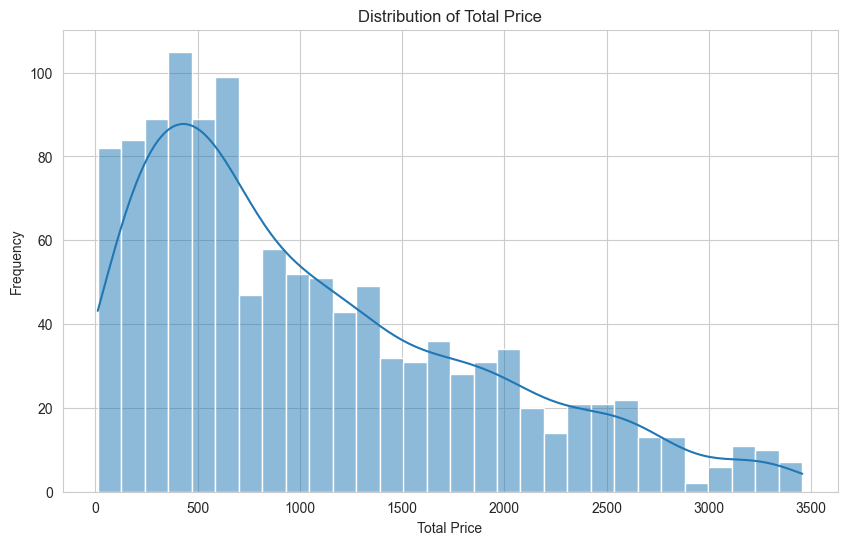

In [15]:
# Distribution of Total Price

plt.figure(figsize=(10,6))
sns.histplot(df['TotalPrice'], bins=30, kde=True)

plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')

plt.show()

### Observation

The distribution of TotalPrice helps identify customer spending behavior and whether most customers make low-value or high-value purchases.

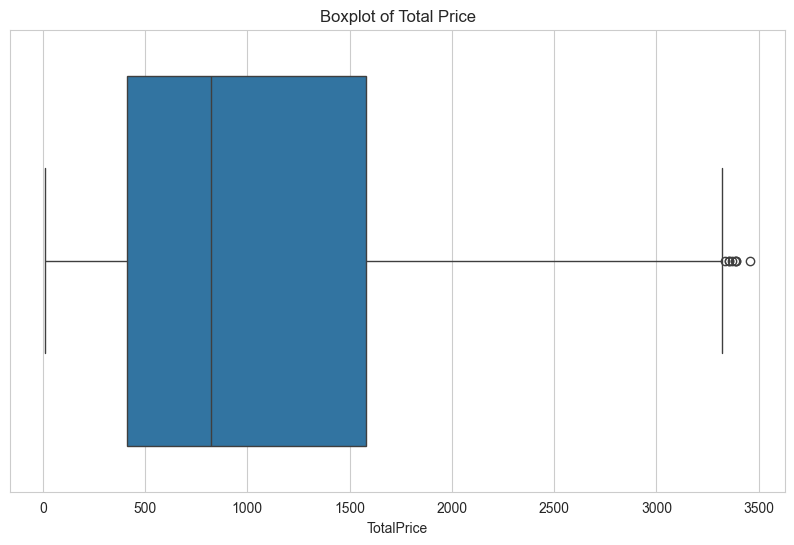

In [46]:
# Boxplot for Total Price

plt.figure(figsize=(10,6))
sns.boxplot(x=df['TotalPrice'])

plt.title('Boxplot of Total Price')

plt.savefig('../visuals/boxplot_total_price.png', bbox_inches='tight')

plt.show()

# Outlier Detection Using IQR Method

In this section, we identify potential outliers in numerical features using the Interquartile Range (IQR) method.

In [17]:
# Detect Outliers Using IQR

numeric_columns = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print(f"Number of Outliers: {outliers.shape[0]}")
    print("-" * 40)

Quantity
Number of Outliers: 0
----------------------------------------
UnitPrice
Number of Outliers: 0
----------------------------------------
ItemsInCart
Number of Outliers: 0
----------------------------------------
TotalPrice
Number of Outliers: 8
----------------------------------------


### Observation

The IQR method helps identify unusually high or low values that may represent VIP customers, bulk purchases, premium orders, or suspicious activity.

In [18]:
# Correlation Matrix

correlation_matrix = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr()

correlation_matrix

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


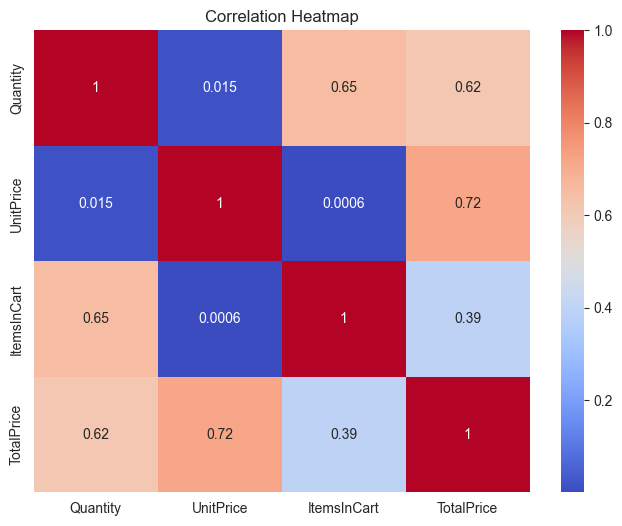

In [45]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.savefig('../visuals/correlation_heatmap.png', bbox_inches='tight')

plt.show()

# Correlation Analysis

This analysis helps identify relationships between numerical variables such as quantity, pricing, cart size, and total order value.

# Product Analysis

This section analyzes product performance based on sales volume and revenue generation.

In [21]:
# Top Selling Products by Quantity

top_products_quantity = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

top_products_quantity.head(10)

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64

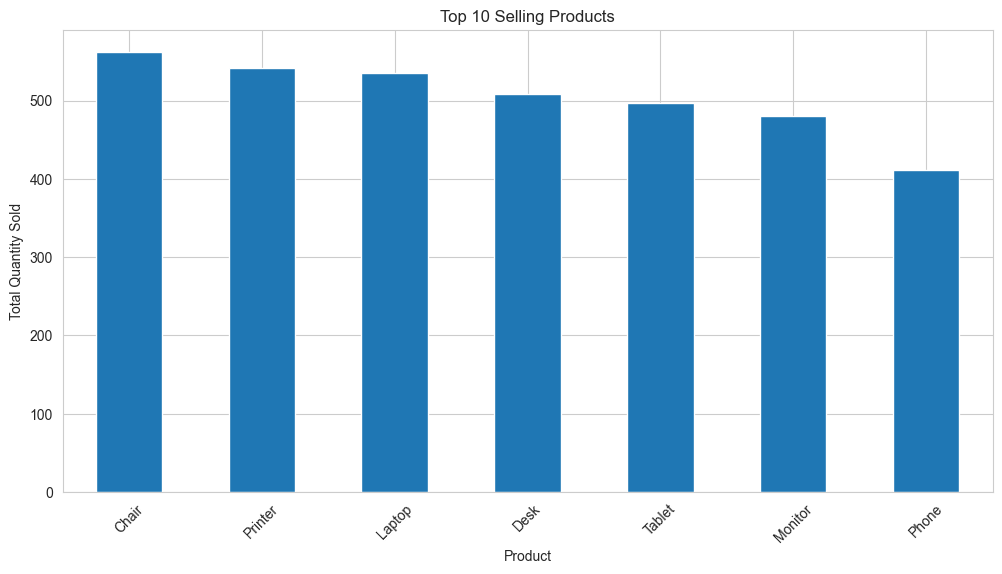

In [48]:
# Visualization of Top Selling Products

plt.figure(figsize=(12,6))

top_products_quantity.head(10).plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')

plt.xticks(rotation=45)

plt.savefig('../visuals/top_selling_products.png', bbox_inches='tight')

plt.show()

In [23]:
# Top Products by Revenue

top_products_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

top_products_revenue.head(10)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

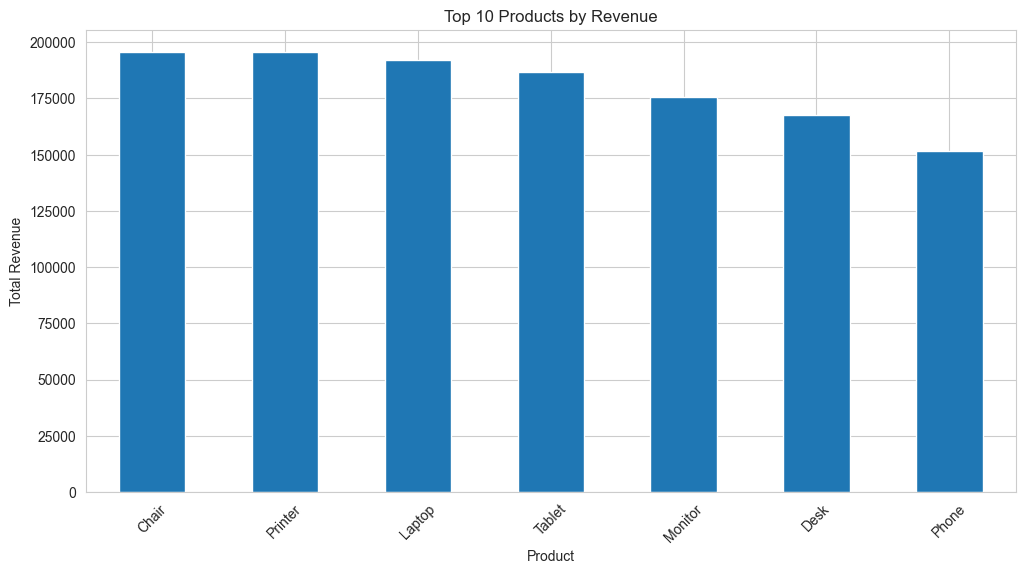

In [49]:
# Visualization of Top Revenue Products

plt.figure(figsize=(12,6))

top_products_revenue.head(10).plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.savefig('../visuals/top_revenue_products.png', bbox_inches='tight')

plt.show()

### Observation

Product analysis helps identify which products contribute most to sales volume and revenue generation. High-performing products may represent strong customer demand or successful pricing strategies.

In [25]:
# Payment Method Distribution

payment_counts = df['PaymentMethod'].value_counts()

payment_counts

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

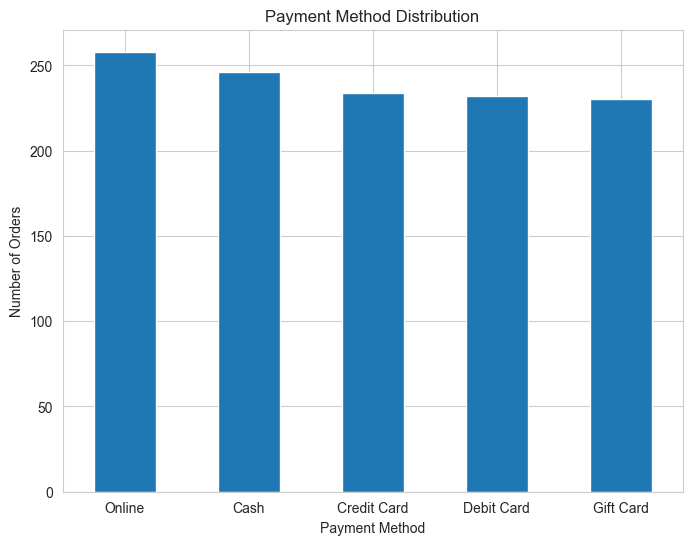

In [47]:
# Payment Method Visualization

plt.figure(figsize=(8,6))

payment_counts.plot(kind='bar')

plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')

plt.xticks(rotation=0)

plt.savefig('../visuals/payment_method_distribution.png', bbox_inches='tight')

plt.show()

# Order Status Analysis

This section analyzes order outcomes such as delivered, cancelled, and returned orders to understand operational performance and customer behavior.

In [27]:
# Order Status Distribution

order_status_counts = df['OrderStatus'].value_counts()

order_status_counts

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

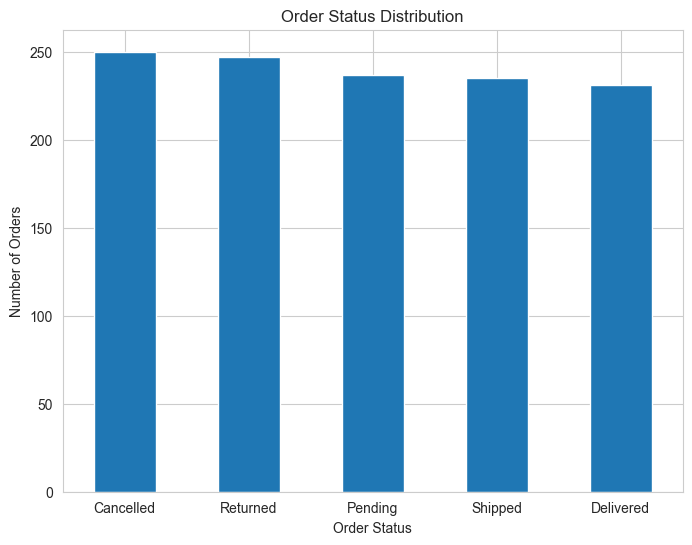

In [50]:
# Order Status Visualization

plt.figure(figsize=(8,6))

order_status_counts.plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')

plt.xticks(rotation=0)

plt.savefig('../visuals/order_status_distribution.png', bbox_inches='tight')

plt.show()

In [29]:
# Order Status Percentage

order_status_percentage = (df['OrderStatus'].value_counts(normalize=True) * 100)

order_status_percentage

OrderStatus
Cancelled    20.833333
Returned     20.583333
Pending      19.750000
Shipped      19.583333
Delivered    19.250000
Name: proportion, dtype: float64

### Observation

Order status analysis helps evaluate operational efficiency and customer satisfaction. High cancellation or return rates may indicate issues related to delivery performance, product expectations, or customer experience.

# Referral Source Analysis

This section evaluates marketing channel performance and customer acquisition effectiveness.

In [30]:
# Referral Source Distribution

referral_counts = df['ReferralSource'].value_counts()

referral_counts

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

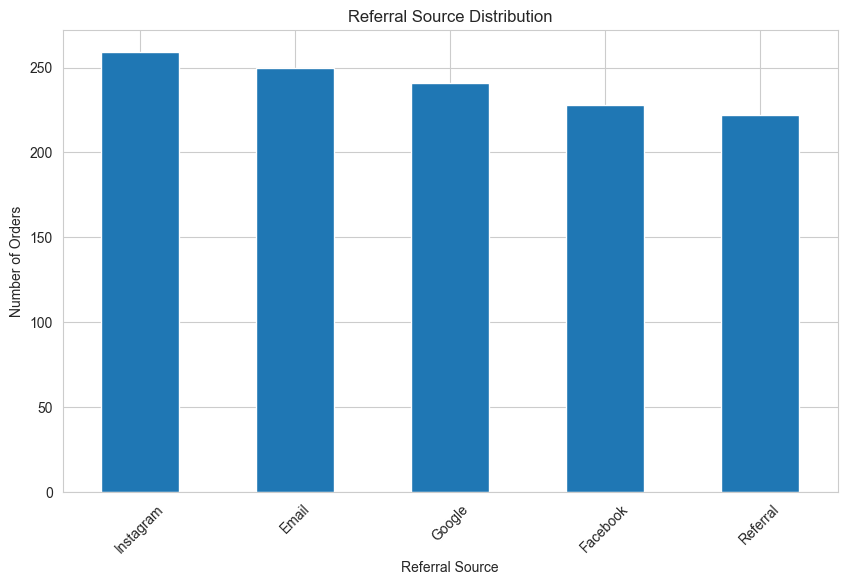

In [51]:
# Referral Source Visualization

plt.figure(figsize=(10,6))

referral_counts.plot(kind='bar')

plt.title('Referral Source Distribution')
plt.xlabel('Referral Source')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.savefig('../visuals/referral_source_distribution.png', bbox_inches='tight')

plt.show()

In [32]:
# Revenue by Referral Source

referral_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

referral_revenue

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

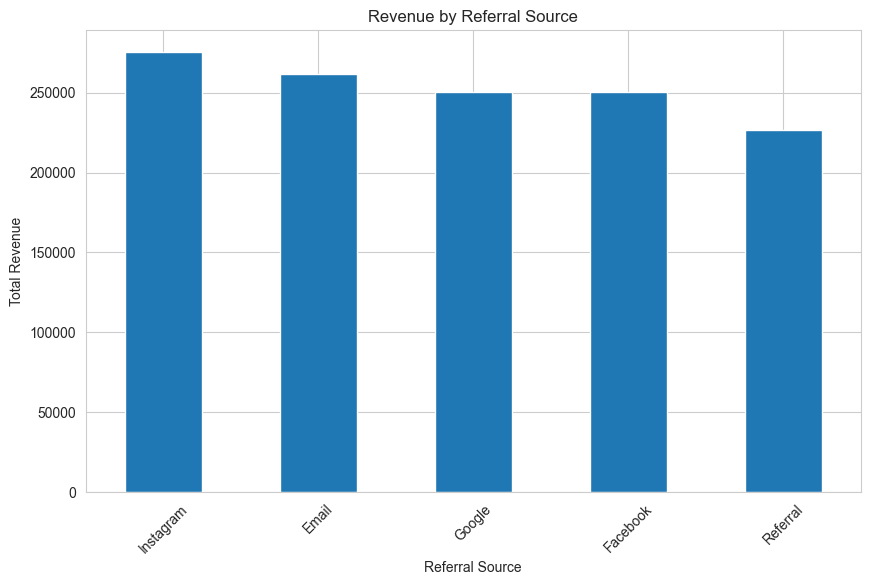

In [52]:
# Revenue by Referral Source Visualization

plt.figure(figsize=(10,6))

referral_revenue.plot(kind='bar')

plt.title('Revenue by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.savefig('../visuals/revenue_by_referral_source.png', bbox_inches='tight')

plt.show()

# Time Series Analysis

This section analyzes sales and revenue trends over time to identify seasonal patterns and business growth behavior.

In [34]:
df['Date'] = pd.to_datetime(df['Date'])

In [35]:
df['Date'].dtype

dtype('<M8[us]')

In [36]:
# Extract Month and Year

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [37]:
# Monthly Revenue Analysis

monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

monthly_revenue

Month
1     124313.23
2     112344.78
3     123840.93
4     109186.05
5     135142.59
6     170616.13
7      85784.64
8      86343.21
9      69321.65
10     89834.82
11     75493.43
12     82540.50
Name: TotalPrice, dtype: float64

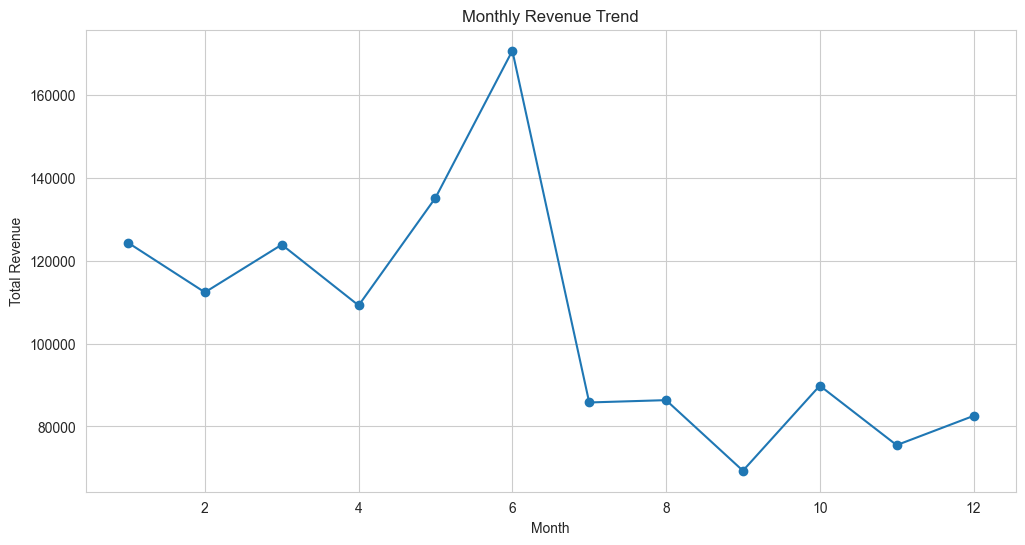

In [53]:
# Monthly Revenue Visualization

plt.figure(figsize=(12,6))

monthly_revenue.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.grid(True)

plt.savefig('../visuals/monthly_revenue_trend.png', bbox_inches='tight')

plt.show()

In [39]:
# Monthly Orders Analysis

monthly_orders = df.groupby('Month')['OrderID'].count()

monthly_orders

Month
1     106
2     106
3     128
4     113
5     120
6     147
7      87
8      79
9      73
10     78
11     76
12     87
Name: OrderID, dtype: int64

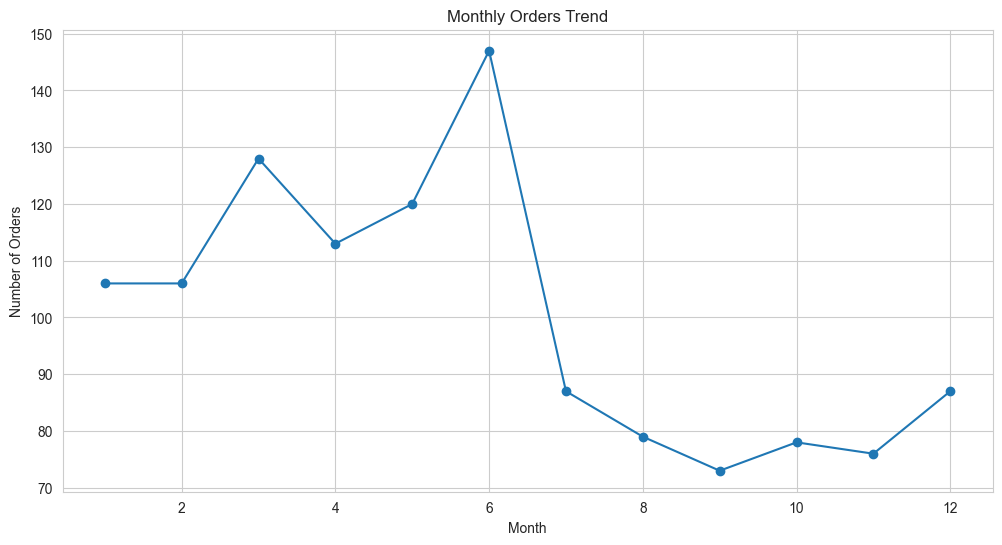

In [54]:
# Monthly Orders Visualization

plt.figure(figsize=(12,6))

monthly_orders.plot(marker='o')

plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.grid(True)

plt.savefig('../visuals/monthly_orders_trend.png', bbox_inches='tight')

plt.show()

### Observation

Time series analysis helps identify seasonal demand patterns, sales fluctuations, and overall business performance trends across different months.

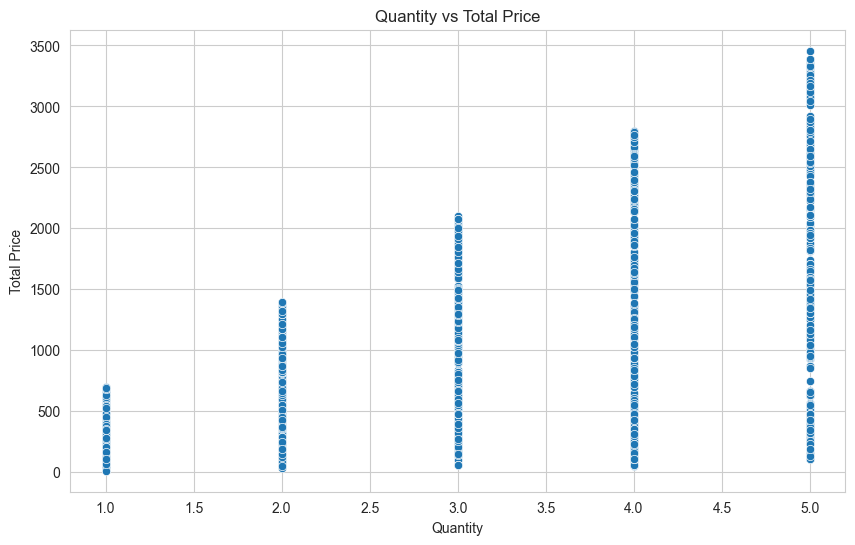

In [55]:
# Scatter Plot: Quantity vs TotalPrice

plt.figure(figsize=(10,6))

sns.scatterplot(x=df['Quantity'], y=df['TotalPrice'])

plt.title('Quantity vs Total Price')
plt.xlabel('Quantity')
plt.ylabel('Total Price')

plt.savefig('../visuals/quantity_vs_total_price.png', bbox_inches='tight')

plt.show()

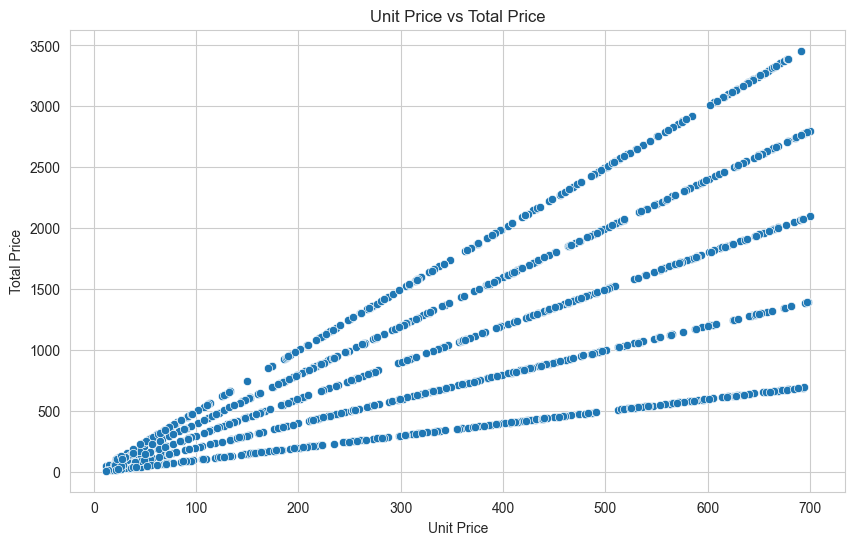

In [56]:
# Scatter Plot: UnitPrice vs TotalPrice

plt.figure(figsize=(10,6))

sns.scatterplot(x=df['UnitPrice'], y=df['TotalPrice'])

plt.title('Unit Price vs Total Price')
plt.xlabel('Unit Price')
plt.ylabel('Total Price')

plt.savefig('../visuals/unit_price_vs_total_price.png', bbox_inches='tight')

plt.show()

# Relationship Analysis

Scatter plots help visualize relationships between numerical variables and reveal potential correlations, spending behavior, and purchasing patterns.

# Business Insights

This section translates analytical findings into meaningful business insights and strategic observations.

## Key Business Insights

### 1. Customer Spending Behavior
The TotalPrice distribution appears right-skewed, indicating that a small percentage of customers contribute disproportionately high revenue. This suggests the presence of high-value or VIP customers.

### 2. Product Performance
Certain products consistently generated higher sales volume and revenue, indicating strong customer demand and potentially successful pricing or marketing strategies.

### 3. Payment Method Preferences
Customers showed preference toward specific payment methods, which may reflect trust, convenience, or accessibility factors.

### 4. Operational Performance
Order status analysis revealed the proportion of delivered, cancelled, and returned orders. High cancellation or return rates may indicate operational inefficiencies or customer expectation mismatches.

### 5. Marketing Effectiveness
Referral source analysis highlighted which acquisition channels generated the highest number of orders and revenue, helping evaluate marketing channel effectiveness.

### 6. Seasonal and Time-Based Trends
Monthly sales trends demonstrated fluctuations in revenue and order volume over time, potentially indicating seasonal purchasing behavior.

### 7. Outlier Observations
Outlier analysis identified unusually large transactions that may represent VIP customers, bulk purchases, premium buyers, or special purchasing events.

# Executive Summary

## Project Objective

The objective of this project was to perform Exploratory Data Analysis (EDA) on an e-commerce dataset to uncover patterns, customer behavior trends, operational insights, and revenue-driving factors.

---

## Methodology

The analysis process included:
- Data understanding and validation
- Descriptive statistical analysis
- Distribution analysis
- Outlier detection using IQR
- Correlation analysis
- Product and revenue analysis
- Payment and order status analysis
- Referral source evaluation
- Time series analysis

---

## Key Findings

- Customer spending behavior showed a right-skewed distribution, indicating that a small group of customers generated significantly higher revenue.
- Several products consistently outperformed others in both sales quantity and revenue contribution.
- Certain payment methods were more commonly used, reflecting customer purchasing preferences.
- Referral source analysis revealed which marketing channels produced stronger customer acquisition results.
- Outlier detection identified high-value transactions that may represent VIP customers or bulk purchasing behavior.
- Monthly revenue trends suggested fluctuations in purchasing activity over time.

---

## Business Recommendations

- Focus marketing efforts on high-performing referral channels.
- Develop loyalty strategies for high-value customers.
- Investigate cancellation and return patterns to improve customer satisfaction.
- Prioritize inventory planning for top-performing products.
- Monitor unusual transaction behavior for fraud prevention and customer segmentation opportunities.

---

## Final Conclusion

This EDA project successfully transformed raw transactional data into meaningful business insights. The analysis demonstrated how statistical exploration and visualization techniques can support data-driven decision-making, customer understanding, and operational improvement.